In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

# Filename: Class04f2_Breast-Cancer-Classification.ipynb
# if necessary:
# pip install scikit-learn
# pip install pandas

In [261]:
# Colab import libraries
# Click only in Colab

import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers import Activation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from keras.models import Sequential
from keras.layers import Dense

In [34]:
# Jupyter Notebook import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K

from sklearn.neural_network import MLPRegressor 
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score


In [35]:
# Loading data from the .csv file if in Colab
# data_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/BCW_dataset.csv', delimiter=',', header=0, index_col=None)

data_raw = pd.read_csv('BCW_dataset.csv', delimiter=',', header=0, index_col=None)
# Head method show first 5 rows of data
print(data_raw.head())



         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [46]:
# Drop unused columns
drop_columns = ['Unnamed: 32', 'id', 'diagnosis']
X = data_raw.drop(drop_columns, axis=1)

# Convert strings -> integers
d = {'M': 0, 'B': 1}

# Define features and labels
y = data_raw['diagnosis'].map(d)

print('X.shape: ',X.shape)
print('y.shape: ',y.shape)
# testing the data values
print(y.values )
y_tmp=y.values
print(y_tmp[0:22])

X.shape:  (569, 30)
y.shape:  (569,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 

['M', 'B']
[212, 357]


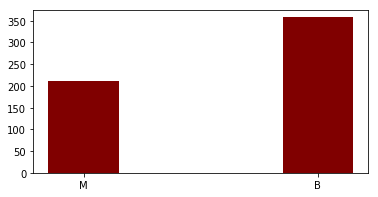

Number of benign cancer:  357
Number of malignant cancer:  212


In [37]:
# Plot number of M - malignant and B - benign cancer

B, M = y.value_counts()
data = {'M':M, 'B':B}
courses = list(data.keys())
values = list(data.values())
print(courses)
print(values)

fig = plt.figure(figsize = (6, 3))
plt.bar(courses,values,color='maroon',width=0.3)
plt.show()
print('Number of benign cancer: ', B)
print('Number of malignant cancer: ', M)


In [47]:
# Example
# One hot encoding
encode_array = OneHotEncoder()
Y = encode_array.fit_transform(y[:, None]).toarray()
print('y[0:5] = ',y[0:5])
print(' ')
print('First five one hot encoded output: ')
print(Y[0:5])

# Scale data to have mean 0 and variance 1 
# which helps the convergence of the neural network
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(' ')
print('First five scaled input features: ')
print(X_scaled[0:5,0:4])

y[0:5] =  0    0
1    0
2    0
3    0
4    0
Name: diagnosis, dtype: int64
 
First five one hot encoded output: 
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]
 
First five scaled input features: 
[[ 1.09706398 -2.07333501  1.26993369  0.9843749 ]
 [ 1.82982061 -0.35363241  1.68595471  1.90870825]
 [ 1.57988811  0.45618695  1.56650313  1.55888363]
 [-0.76890929  0.25373211 -0.59268717 -0.76446379]
 [ 1.75029663 -1.15181643  1.77657315  1.82622928]]


c:\users\gpang\appdata\local\programs\python\python36\lib\site-packages\sklearn\preprocessing\_encoders.py:371: FutureWarning: The handling of integer data will change in version 0.22. Currently, the categories are determined based on the range [0, max(values)], while in the future they will be determined based on the unique values.
If you want the future behaviour and silence this warning, you can specify "categories='auto'".
In case you used a LabelEncoder before this OneHotEncoder to convert the categories to integers, then you can now use the OneHotEncoder directly.
  warnings.warn(msg, FutureWarning)


In [52]:

# Split dataset into training (75%) and test (25%) set
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.25, random_state=2)


print('X.shape = ', X.shape)
print('Y.shape = ', Y.shape)
num_features = X.shape[1]
num_classes = Y.shape[1]
print('num_features = ',num_features)
print('num_classes = ',num_classes)

# Normalization of the data
X_train_n = (X_train-X_train.mean())/(X_train.max()-X_train.min())
X_test_n = (X_test-X_train.mean())/(X_test.max()-X_test.min())
print('X_train_n.shape = ', X_train_n.shape)
print('X_test_n.shape = ', X_test_n.shape)
print('Y_train.shape = ', Y_train.shape)
print('Y_test.shape = ', Y_test.shape)
print('Y_train[0:3] is ')
print(Y_train[0:3])

X.shape =  (569, 30)
Y.shape =  (569, 2)
num_features =  30
num_classes =  2
X_train_n.shape =  (426, 30)
X_test_n.shape =  (143, 30)
Y_train.shape =  (426, 2)
Y_test.shape =  (143, 2)
Y_train[0:3] is 
[[1. 0.]
 [1. 0.]
 [0. 1.]]


In [30]:
# define the model structure
# Dense : a regular fully connected layer

# The following is a simple one-hidden layer ANN; 
# 
# Define the number of hidden nodes
num_hidden_nodes = 50

def model_1():
    # create model
    # ..........................
    
    
    
    # ...........................
    # Choice of optimizer: adam (adaptive moment estimation), 
    # or sgd (Stochastic gradient descent),
    return model

# build the model
model = model_1()



In [64]:
# Training of the ANN
# Use of validation data
#
# 

# history = model.fit( ....)

# Testing of the trained ANN with X_test_n

#score = model.evaluate(....)
#print('Test loss:', score[0])
#print('Test accuracy:', score[1])


In [61]:
# Result using the first test data, output from ANN is y_ANN_output
# Desired output is Y_test[0]
y_ANN_output=model.predict(X_test_n[0,None])
print('ANN output =    ', y_ANN_output)
print('Desired output = ', Y_test[0])
#-----------------------------------------------------------------
# ANN to predict the entire test data
# ANN output is Y_ANN, with input X_test_n. Desired output is Y_test
Y_ANN=model.predict(X_test_n)

# Use of np.argmax : 0 is first position; 1 is second position
y_ANN=np.argmax(Y_ANN, axis=1)
y_test=np.argmax(Y_test, axis=1)
print(y_test.shape,y_ANN.shape)
print('=============================')
print('Y_ANN ', Y_ANN[0:5,:])
print('y_ANN ', y_ANN[0:5])
print('Y_test ', Y_test[0:5])
print('y_test ', y_test[0:5])

print('-----------------------------')
print('Confusion Matrix is ')
print(confusion_matrix(y_test,y_ANN))
print(precision_score(y_test,y_ANN))
print(recall_score(y_test,y_ANN))
print(f1_score(y_test,y_ANN))


ANN output =     [[0.22932747 0.77067256]]
Desired output =  [0. 1.]
(143,) (143,)
Y_ANN  [[2.2932747e-01 7.7067256e-01]
 [4.9362698e-01 5.0637299e-01]
 [1.7313770e-04 9.9982685e-01]
 [1.0000000e+00 3.2119909e-19]
 [2.3828539e-01 7.6171464e-01]]
y_ANN  [1 1 1 0 1]
Y_test  [[0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]
y_test  [1 1 1 0 1]
-----------------------------
Confusion Matrix is 
[[54  2]
 [ 5 82]]
0.9761904761904762
0.9425287356321839
0.95906432748538


In [62]:
# More elegant display
print("Precision score: {}".format(round(precision_score(y_test, y_ANN),3)))
print("Recall score: {}".format(round(recall_score(y_test, y_ANN),3)))
print("F1 Score: {}".format(round(f1_score(y_test, y_ANN),3)))

Precision score: 0.976
Recall score: 0.943
F1 Score: 0.959


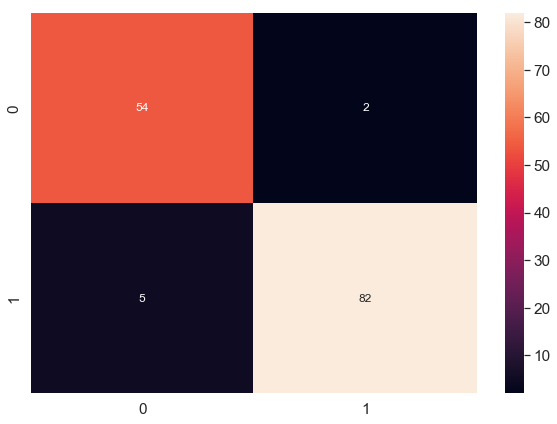

In [41]:
# More elegant display of confusion matrix
cm = confusion_matrix(y_test,y_ANN)
df_cm = pd.DataFrame(cm, range(2),range(2))
plt.figure(figsize=(10,7))
sns.set(font_scale=1.4)#for label size
cm_plot = sns.heatmap(df_cm, annot=True, fmt='n', annot_kws={"size": 12})


In [63]:
# To show the performance of the ANN during training
# The information has already been saved in "history"

# codes to show performance curves here